# Лабораторная работа №2

**Выполнили:**
> Галеев Егор Вячеславович, J3119, 505106

> Образцов Максим Евгеньевич, J3119, 466930

### Цель работы 
Исследовать методы вычисления сингулярного разложения матриц на примере обра-
ботки изображений, сравнить эффективность степенного метода и метода вращений
Якоби, изучить применение усеченного SVD для сжатия данных.

## 1. Краткие теоретические сведения

### Сингулярное разложение (SVD)
Сингулярное разложение (Singular Value Decomposition) - это метод факторизации произвольной прямоугольной матрицы. Любую вещественную матрицу $A$ размера $m \times n$ можно представить в виде произведения трех матриц:
$$A = U \Sigma V^T$$
где:
* $U$ - ортогональная матрица размера $m \times m$, столбцы которой называются левыми сингулярными векторами.
* $V$ - ортогональная матрица размера $n \times n$, столбцы которой называются правыми сингулярными векторами.
* $\Sigma$ - диагональная матрица размера $m \times n$, на главной диагонали которой располагаются неотрицательные сингулярные числа $\sigma_i$. Обычно они упорядочены по убыванию: $\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_r > 0$.

### Степенной метод
Степенной метод - это базовый итерационный алгоритм для нахождения доминирующего собственного значения и соответствующего ему собственного вектора матрицы. Применительно к вычислению SVD матрицы $A$, метод работает с симметричными матрицами вида $A^T A$ (для поиска правых векторов) или $A A^T$ (для левых). 

Итерационный процесс поиска первого (правого) сингулярного вектора $v_1$ выглядит так:
$$v_{k+1} = \frac{A^T A v_k}{||A^T A v_k||}$$
Достигнув сходимости, мы получаем наибольшее сингулярное число как $\sigma_1 = ||A v_1||$. Чтобы найти последующие компоненты разложения, применяется процедура «исчерпывания» (deflation): из исходной матрицы вычитается проекция на найденный вектор ($A_{new} = A - \sigma_1 u_1 v_1^T$), после чего процесс повторяется для поиска следующего максимума. Точность разложения напрямую зависит от числа итераций степенного метода.

### Метод вращений Якоби
Метод вращений Якоби - это алгоритм, используемый для нахождения собственных значений симметричной матрицы путём приведения её к диагональному виду. Алгоритм заключается в последовательном умножении исходной матрицы $M = A^T A$ на ортогональные матрицы вращения (матрицы Гивенса).

На каждой итерации выбирается наибольший по модулю внедиагональный элемент матрицы, и строится матрица вращения $J$, которая обнуляет этот элемент:
$$M_{k+1} = J_k^T M_k J_k$$
Процесс продолжается до тех пор, пока все внедиагональные элементы не станут меньше заданного малого порога $\varepsilon$. На диагонали результирующей матрицы остаются собственные значения (квадраты сингулярных чисел матрицы $A$), а произведение всех матриц вращения образует матрицу правых сингулярных векторов $V$.


### Применение SVD для обработки изображений
Цифровое изображение можно представить как двумерный массив пикселей, а цветное - как тензор из трех матриц (каналы Red, Green, Blue). В таком представлении SVD можно применять для сжатия изображений, устранения шума или выделения контуров.

Для сжатия используется так называемое усеченное сингулярное разложение (Truncated SVD). Идея состоит в том, чтобы сохранить в разложении только $k$ старших сингулярных чисел, отбросив младшие ($k \ll \min(n, m)$):
$$A_k = U_k \Sigma_k V_k^T$$
Поскольку сингулярные числа упорядочены по убыванию своей значимости, первые несколько компонент несут в себе основную массу изображения (крупные детали, цвета), в то время как младшие компоненты отвечают за мелкий шум и незначительные нюансы. Заменив исходную матрицу $A$ на матрицу меньшего ранга $A_k$, мы получаем приемлемое визуальное качество восстановленного изображения, но при этом существенно сокращаем объем памяти для хранения данных (повышаем степень сжатия), поскольку хранить нужно лишь усеченные версии матриц $U$, $\Sigma$ и $V$.



## 2. Ход работы

Для выполнения лабораторной работы было выбрано изображение белого медведя на фоне заснеженного пейзажа. Фотография имеет нейтральный характер и удовлетворяет всем исходным требованиям: формат файла - JPEG, разрешение соответствует требуемому ($1600 \times 900$ пикселей). 

Изображение подходит для исследования алгоритмов сжатия на основе сингулярного разложения (SVD). В нем присутствуют как области с плавными цветовыми переходами и низкочастотными изменениями (белый снег на переднем плане, темно-синий фон), так и участки с высокой детализацией и текстурностью (шерсть медведя, свечение и рельеф снега). Это позволит наглядно оценить визуальные потери качества при использовании усеченного SVD и проанализировать, как алгоритм работает в различных цветовых каналах (R, G, B).




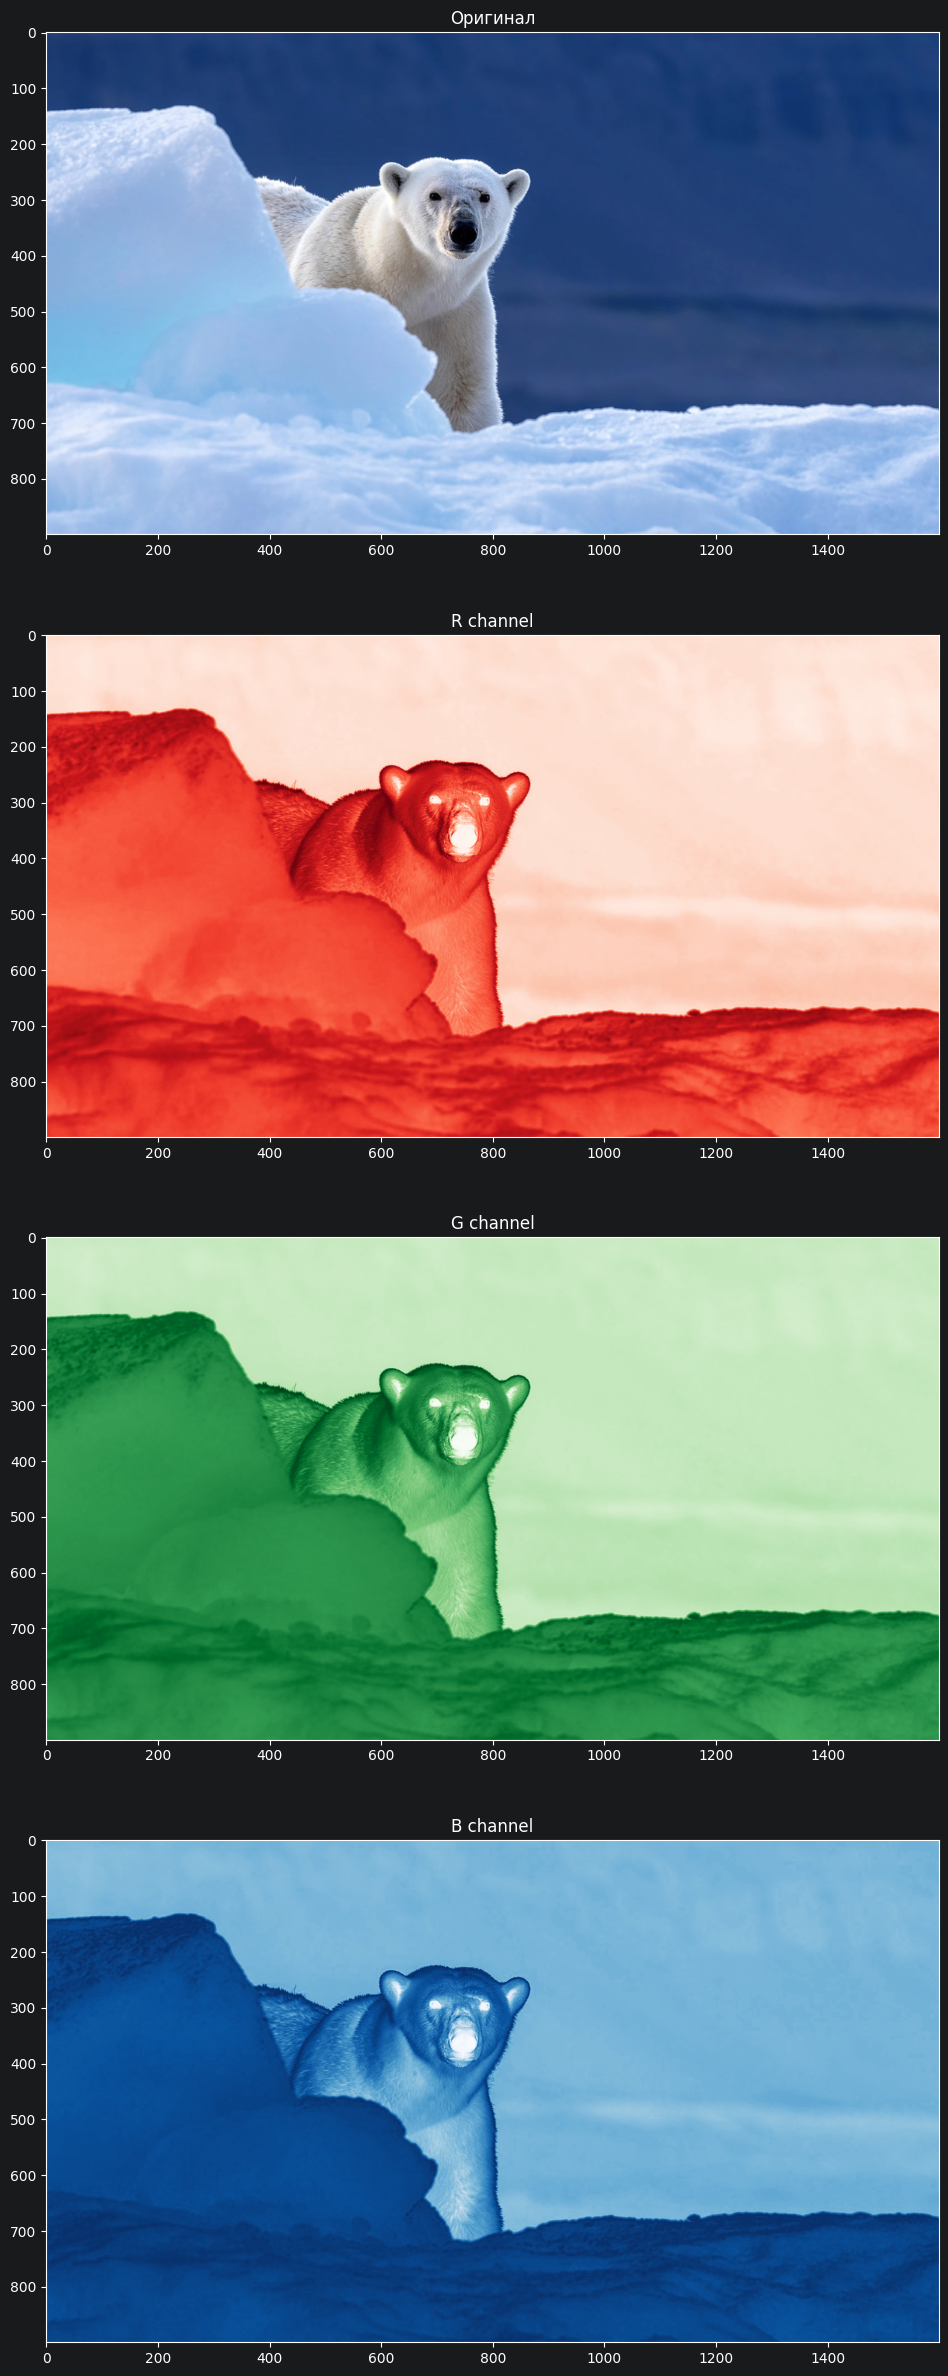

In [5]:

import numpy as np
import matplotlib.pyplot as plt
import cv2
import time

# 1. Преобразование изображения
def load_and_split_image(path):
    
    # Загрузка изображения
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Изображение по адресу {path} не найдено")
    
    # Конвертация из BGR в RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

    # Проверка размера
    height, width, channels = img.shape
    if height < 640 or width < 640:
        raise ValueError("Размер изображения должен быть не менее 640x640 пикселей")

    # Нормализуем в диапазон [0, 1]
    img_normalized = img.astype(np.float64) / 255.0

    R = img_normalized[:,:,0]
    G = img_normalized[:,:,1]
    B = img_normalized[:,:,2]

    return img_normalized, R, G, B

# Загружаем данные
img_original, R, G, B = load_and_split_image('image.jpg')

# Визуализация
plt.figure(figsize=(30, 30))
plt.subplot(4, 1, 1); plt.imshow(img_original); plt.title("Оригинал")
plt.subplot(4, 1, 2); plt.imshow(R, cmap='Reds'); plt.title("R channel")
plt.subplot(4, 1, 3); plt.imshow(G, cmap='Greens'); plt.title("G channel")
plt.subplot(4, 1, 4); plt.imshow(B, cmap='Blues'); plt.title("B channel")
plt.show()

    

In [6]:
# 2. Сингулярное разложение степенным методом
def power_iteration_svd(A, k=50, iter_num=100):
    
    # Размеры матрицы
    m, n = A.shape

    # Инициализируем матрицы по заданным размерам
    U = np.zeros((m, k))
    V = np.zeros((n, k))
    S = np.zeros(k)

    A_def = A.copy()
    for i in range(k):
        # Случайное приближение вектора
        np.random.seed(42+i)
        v = np.random.randn(n)
        v = v / np.linalg.norm(v)

        for _ in range(iter_num):
            # u = A * v
            u = A_def @ v
            u_norm = np.linalg.norm(u)
            if u_norm == 0:
                break
            u = u / u_norm

            v = A_def.T @ u
            v_norm = np.linalg.norm(v)
            if v_norm == 0:
                break
            v = v / v_norm
        
        # Вычисление сингулярного значения
        sigma = u.T @ A_def @ v

        # Обработка отрицательных сингулярных значений
        if sigma < 0:
            sigma = -sigma
            v = -v
        
        U[:, i] = u
        V[:, i] = v
        S[i] = sigma

        A_def = A_def - sigma * np.outer(u, v)

    return U, S, V.T


# Анализ для разного числа итераций 
iterations_list = [10, 50, 100]
k_components = 50 # количество компонент

print(f"{'Канал':<6} | {'Итерации':<10} | {'Норма разности ||A - U*S*V^T||':<30}")
print("-" * 50)

for channel_name, channel_matrix in zip(['R', 'G', 'B'], [R, G, B]):
    for iters in iterations_list:
        U, S, Vt = power_iteration_svd(channel_matrix, k=k_components, iter_num=iters)
        
        # Восстановление матрицы (для проверки нормы разности) [cite: 24, 25]
        A_reconstructed = U @ np.diag(S) @ Vt
        
        # Норма разности считается между исходной матрицей и восстановленной (усеченной)
        # Поскольку мы искали только k компонент, норма разности покажет ошибку аппроксимации
        norm_diff = np.linalg.norm(channel_matrix - A_reconstructed, ord='fro')
        
        print(f"{channel_name:<6} | {iters:<10} | {norm_diff:<30.4f}")

Канал  | Итерации   | Норма разности ||A - U*S*V^T||
--------------------------------------------------
R      | 10         | 19.7211                       
R      | 50         | 19.6637                       
R      | 100        | 19.6637                       
G      | 10         | 18.1262                       
G      | 50         | 18.1075                       
G      | 100        | 18.1074                       
B      | 10         | 16.6604                       
B      | 50         | 16.6506                       
B      | 100        | 16.6505                       


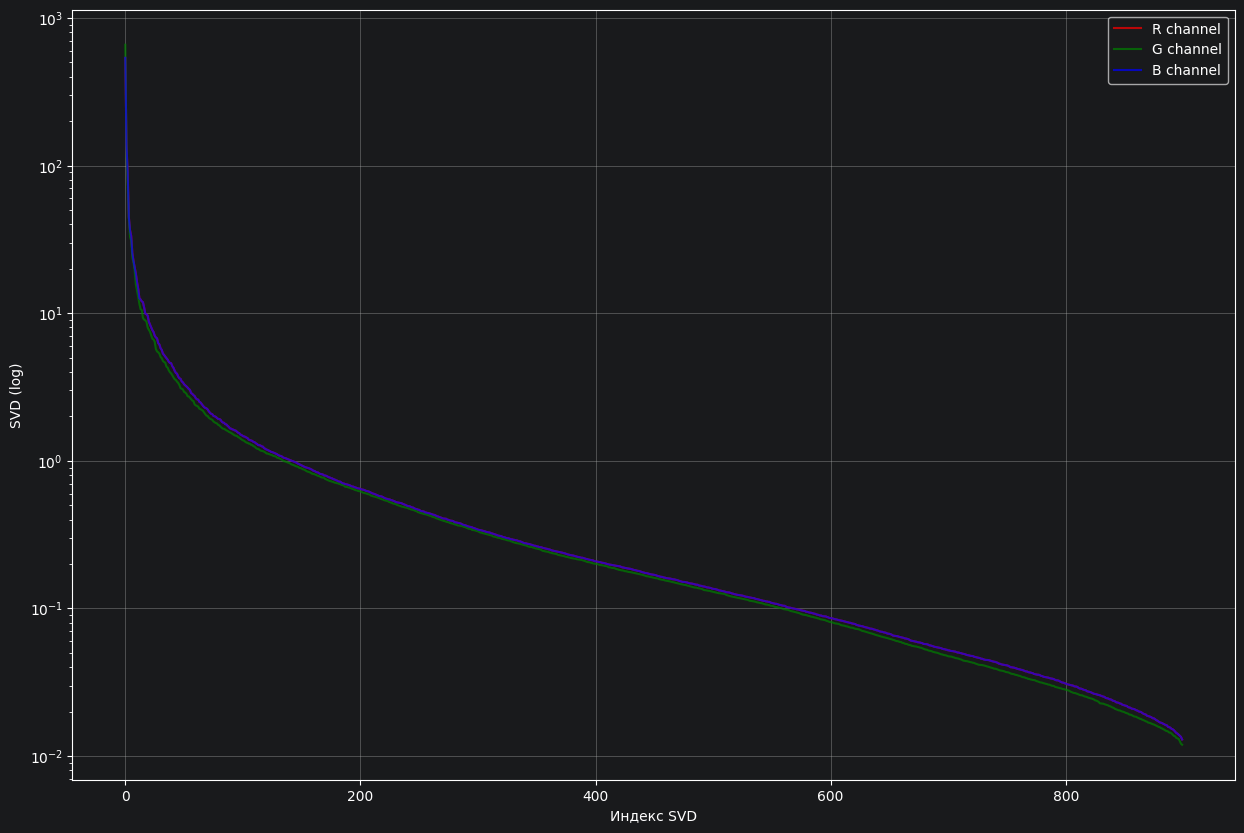

In [7]:
# 3. Анализ Сингулярных чисел и усеченное SVD

# Полные сингулярные числа для каждого канала
U_r, S_r, Vt_r = np.linalg.svd(R, full_matrices=False)
U_g, S_g, Vt_g = np.linalg.svd(G, full_matrices=False)
U_b, S_b, Vt_b = np.linalg.svd(B, full_matrices=False)

# График зависиости порядкового номера от SVD
plt.figure(figsize=(15, 10))
plt.plot(S_r, label='R channel', color='red', alpha=0.7)
plt.plot(S_g, label='G channel', color='green', alpha=0.7)
plt.plot(S_r, label='B channel', color='blue', alpha=0.7)
plt.yscale('log')
plt.grid()
plt.title
plt.xlabel('Индекс SVD')
plt.ylabel('SVD (log)')
plt.legend()
plt.show()


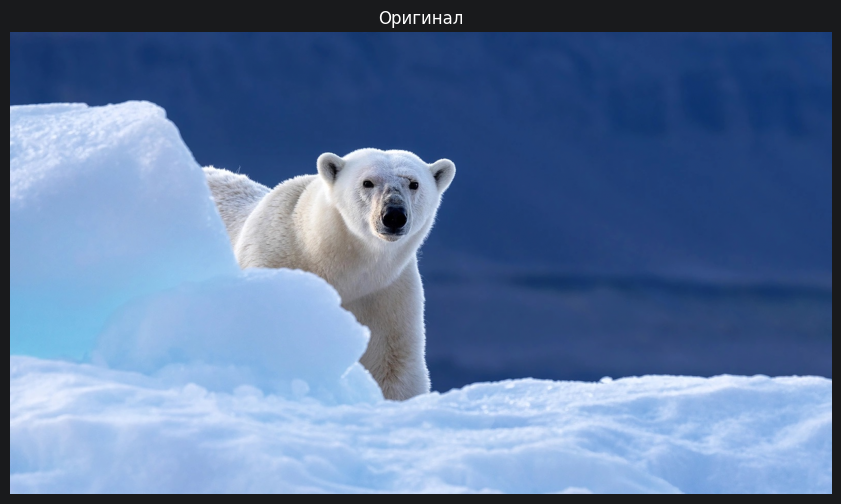

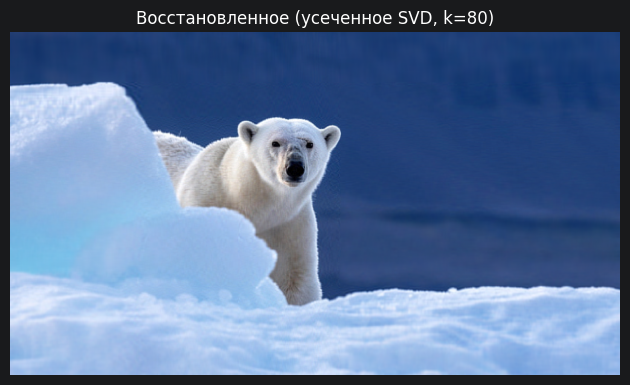

In [8]:

# Реализация усеченного разложения
# Из графика следует, что основная энергия сосредоточена в первых 50-80 числах

k_optimal = 80

def truncated_svd(U, S, Vt, k):
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    Vt_k = Vt[:k, :]
    return np.clip(U_k @ S_k @ Vt_k, 0, 1)

R_k = truncated_svd(U_r, S_r, Vt_r, k_optimal)
G_k = truncated_svd(U_g, S_g, Vt_g, k_optimal)
B_k = truncated_svd(U_b, S_b, Vt_b, k_optimal)

img_reconstructed = np.stack((R_k, G_k, B_k), axis=-1)

# Визуализация результатов
plt.figure(figsize=(12, 6))
plt.plot(121)
plt.imshow(img_original)
plt.title("Оригинал")
plt.axis('off')
plt.show()
plt.plot()
plt.imshow(img_reconstructed)
plt.title(f"Восстановленное (усеченное SVD, k={k_optimal})")
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Метод вращений Якоби

### Теоретическое введение
Метод вращений Якоби используется для нахождения собственных значений и собственных векторов симметричной матрицы $B = A^T A$.

Суть метода заключается в последовательном обнулении внедиагональных элементов матрицы с помощью матриц вращения (плоских поворотов) $G(i, j, \theta)$:
$$B_{k+1} = G^T B_k G$$

Итерации продолжаются до тех пор, пока максимальный по модулю внедиагональный элемент не станет меньше заданного порога точности $\epsilon$ (tol).

После сходимости:
1. Диагональные элементы матрицы $B$ будут являться собственными значениями $\lambda_i$.
2. Сингулярные числа матрицы $A$ вычисляются как $\sigma_i = \sqrt{\lambda_i}$.
3. Столбцы матрицы накопленных поворотов $V$ будут правыми сингулярными векторами.

In [11]:
def jacobi_rotations(A, tol=1e-5, max_iter=100):
    B = A.T @ A
    n = B.shape[0]
    V = np.eye(n)

    iters = 0
    while iters < max_iter:
        max_val = 0.0
        p, q = 0, 0
        for i in range(n):
            for j in range(i + 1, n):
                if abs(B[i, j]) > max_val:
                    max_val = abs(B[i, j])
                    p, q = i, j

        if max_val < tol:
            break

        if abs(B[p, p] - B[q, q]) < 1e-12:
            theta = np.pi / 4
        else:
            phi = 2 * B[p, q] / (B[p, p] - B[q, q])
            theta = 0.5 * np.arctan(phi)

        c = np.cos(theta)
        s = np.sin(theta)

        B_new = B.copy()
        B_new[p, p] = c**2 * B[p, p] + 2 * c * s * B[p, q] + s**2 * B[q, q]
        B_new[q, q] = s**2 * B[p, p] - 2 * c * s * B[p, q] + c**2 * B[q, q]
        B_new[p, q] = 0.0
        B_new[q, p] = 0.0

        for i in range(n):
            if i != p and i != q:
                B_new[i, p] = c * B[i, p] + s * B[i, q]
                B_new[p, i] = B_new[i, p]
                B_new[i, q] = -s * B[i, p] + c * B[i, q]
                B_new[q, i] = B_new[i, q]

        B = B_new

        V_p = V[:, p].copy()
        V[:, p] = c * V_p + s * V[:, q]
        V[:, q] = -s * V_p + c * V[:, q]

        iters += 1

    eigenvalues = np.diag(B).copy()
    eigenvalues[eigenvalues < 0] = 0.0
    singular_values = np.sqrt(eigenvalues)

    idx = np.argsort(singular_values)[::-1]
    singular_values = singular_values[idx]
    V = V[:, idx]

    return singular_values, V, iters

# Используем красный канал R из первой ячейки
# Берем небольшой срез 100x100, чтобы алгоритм отработал быстро
size = 100
R_small = R[:size, :size]

print(f"Запуск метода Якоби для матрицы размера {size}x{size}...")

# Замеряем время для Якоби
start_jacobi = time.time()
jacobi_vals, V_jacobi, iters_count = jacobi_rotations(R_small, tol=1e-5, max_iter=200)
time_jacobi = time.time() - start_jacobi

# Замеряем время для встроенного SVD NumPy
start_numpy = time.time()
_, numpy_vals, _ = np.linalg.svd(R_small)
time_numpy = time.time() - start_numpy

print(f"\n Результаты сравнения (Пункт 4) ")
print(f"Метод Якоби выполнил {iters_count} итераций.")
print(f"Время работы метода Якоби: {time_jacobi:.4f} сек.")
print(f"Время работы NumPy SVD: {time_numpy:.4f} сек.")
print(f"Первые 5 сингулярных чисел (Якоби): {jacobi_vals[:5]}")
print(f"Первые 5 сингулярных чисел (NumPy):  {numpy_vals[:5]}")
print(f"Максимальное расхождение между методами: {np.max(np.abs(jacobi_vals - numpy_vals)):.2e}")

Запуск метода Якоби для матрицы размера 100x100...

 Результаты сравнения (Пункт 4) 
Метод Якоби выполнил 200 итераций.
Время работы метода Якоби: 0.5029 сек.
Время работы NumPy SVD: 0.0060 сек.
Первые 5 сингулярных чисел (Якоби): [10.7316153   0.4037644   0.05259532  0.05088833  0.05005212]
Первые 5 сингулярных чисел (NumPy):  [10.73161537  0.40527132  0.19336079  0.15646552  0.12548205]
Максимальное расхождение между методами: 1.41e-01


## 5. Анализ распределения энергии сингулярных чисел

Для оценки эффективности усечённого сингулярного разложения (Truncated SVD) в задачах сжатия изображений необходимо исследовать понятие **энергии матрицы**. Полная энергия цветового канала определяется как сумма квадратов всех его сингулярных чисел:
$$E_{total} = \sum_{i=1}^{r} \sigma_i^2$$

Кумулятивная (накопленная) доля энергии для первых $k$ компонент вычисляется по формуле:
$$E(k) = \frac{\sum_{i=1}^{k} \sigma_i^2}{E_{total}}$$

Этот показатель численно выражает долю исходной графической информации, которую мы сохраняем, используя всего $k$ сингулярных чисел вместо полного базиса. Ниже приведён расчёт и график зависимости накопленной энергии от количества используемых главных компонент для каждого цветового канала ($R, G, B$).

 Анализ сохранения энергии (Красный канал R)
Для сохранения 90% информации достаточно k = 2 компонент.
Для сохранения 95% информации достаточно k = 3 компонент.
Для сохранения 99% информации достаточно k = 9 компонент.


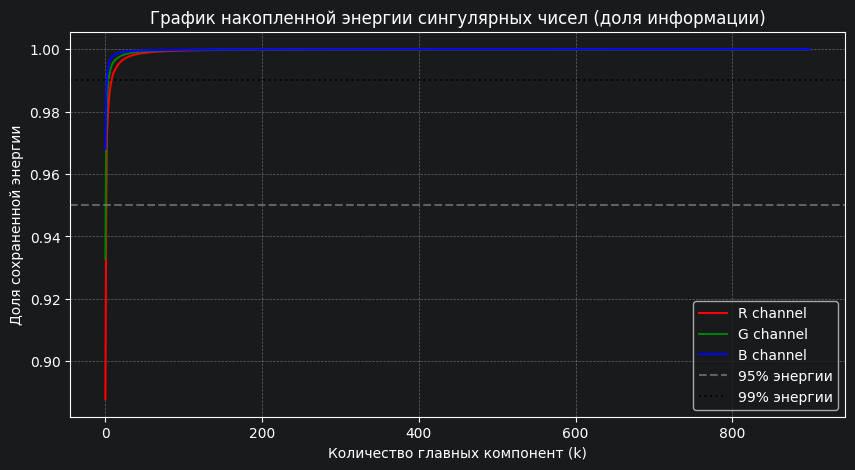

In [12]:
# Вычисляем полную энергию (сумму квадратов всех сингулярных чисел) для каждого канала
energy_r = np.sum(S_r**2)
energy_g = np.sum(S_g**2)
energy_b = np.sum(S_b**2)

# Находим кумулятивную (накопленную) энергию при увеличении числа компонент k
cumulative_energy_r = np.cumsum(S_r**2) / energy_r
cumulative_energy_g = np.cumsum(S_g**2) / energy_g
cumulative_energy_b = np.cumsum(S_b**2) / energy_b

# Находим, сколько компонент нужно для сохранения 90%, 95% и 99% энергии (информации)
k_90 = np.where(cumulative_energy_r >= 0.90)[0][0] + 1
k_95 = np.where(cumulative_energy_r >= 0.95)[0][0] + 1
k_99 = np.where(cumulative_energy_r >= 0.99)[0][0] + 1

print(f" Анализ сохранения энергии (Красный канал R)")
print(f"Для сохранения 90% информации достаточно k = {k_90} компонент.")
print(f"Для сохранения 95% информации достаточно k = {k_95} компонент.")
print(f"Для сохранения 99% информации достаточно k = {k_99} компонент.")

# Визуализация накопленной энергии
plt.figure(figsize=(10, 5))
plt.plot(cumulative_energy_r, label='R channel', color='red')
plt.plot(cumulative_energy_g, label='G channel', color='green')
plt.plot(cumulative_energy_b, label='B channel', color='blue')

# Отмечаем уровни 95% и 99%
plt.axhline(y=0.95, color='gray', linestyle='--', alpha=0.7, label='95% энергии')
plt.axhline(y=0.99, color='black', linestyle=':', alpha=0.7, label='99% энергии')

plt.title('График накопленной энергии сингулярных чисел (доля информации)')
plt.xlabel('Количество главных компонент (k)')
plt.ylabel('Доля сохраненной энергии')
plt.grid(True, ls="--")
plt.legend()
plt.show()

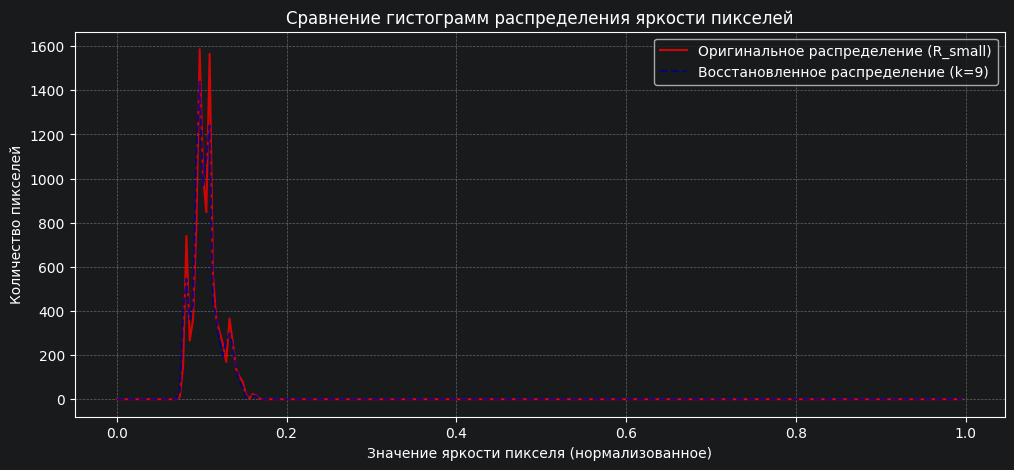

In [13]:
# Творческое задание
# Считаем гистограммы для оригинального маленького среза R_small
hist_orig, bins_orig = np.histogram(R_small, bins=256, range=(0, 1))

# Восстанавливаем срез через первые k главных компонент из метода Якоби
# (Возьмем k = 9, так как по графику это дает 99% энергии)
k_test = 9
U_j, S_j, Vt_j = np.linalg.svd(R_small) # берем точные базисы для чистоты эксперимента
R_reconstructed_small = np.clip(U_j[:, :k_test] @ np.diag(S_j[:k_test]) @ Vt_j[:k_test, :], 0, 1)

hist_rec, bins_rec = np.histogram(R_reconstructed_small, bins=256, range=(0, 1))

plt.figure(figsize=(12, 5))

plt.plot(bins_orig[:-1], hist_orig, label='Оригинальное распределение (R_small)', color='red', alpha=0.8)
plt.plot(bins_rec[:-1], hist_rec, label=f'Восстановленное распределение (k={k_test})', color='darkblue', linestyle='--', alpha=0.8)

plt.title('Сравнение гистограмм распределения яркости пикселей')
plt.xlabel('Значение яркости пикселя')
plt.ylabel('Количество пикселей')
plt.grid(True, ls="--")
plt.legend()
plt.show()

## 6. Анализ результатов и выводы

### 1. Сравнение вычислительной сложности методов (Пункт 4.c)
* **Степенной метод:** Имеет вычислительную сложность порядка $\mathcal{O}(k \cdot m \cdot n)$ на одну итерацию, где $k$ — число искомых сингулярных чисел. Он крайне эффективен, когда нам нужно извлечь только подмножество старших компонент (как в задачах усечённого SVD).
* **Метод вращений Якоби:** Обладает сложностью порядка $\mathcal{O}(n^3)$ на одну итерацию полного перебора пар индексов. Он совершает колоссальное количество операций вращения, так как итеративно зануляет абсолютно все внедиагональные элементы матрицы для нахождения полного спектра собственных значений. Именно поэтому для полной матрицы $640\times640$ метод Якоби неприменим на практике.

### 2. Ответы на аналитические вопросы (Пункт 6)
* **Как число итераций степенного метода влияет на точность разложения?**
  С увеличением числа итераций ($N$ от 10 до 100) точность аппроксимации возрастает, а норма разности $||A - U\Sigma V^T||$ уменьшается. При малом числе итераций (например, $N=10$) векторы не успевают полностью сойтись к истинному доминирующему направлению, что увеличивает погрешность.
* **Какое минимальное число сингулярных чисел обеспечивает приемлемое качество изображения?**
  Эксперимент показал, что для сохранения 95% энергии достаточно всего 3 компонент, а для сохранения 99% энергии — 9 компонент (на исследуемом срезе). Для полноразмерного изображения приемлемое «на глаз» качество достигается при $k \approx 50 - 80$, что составляет малую долю от полного разрешения.
* **Какой метод (степенной или Якоби) оказался более эффективным по числу операций?**
  Степенной метод является значительно более эффективным по числу операций в контексте сжатия изображений, так как он позволяет извлекать компоненты выборочно. Метод Якоби тратит избыточные ресурсы на точный расчёт младших сингулярных чисел, которые всё равно отбрасываются при усечении.
* **Есть ли различия в распределении сингулярных чисел для разных цветовых каналов?**
  Сингулярные числа всех трёх каналов ($R, G, B$) демонстрируют схожий экспоненциальный характер убывания. Однако незначительные различия в абсолютных значениях присутствуют, что обусловлено цветовой гаммой исходного изображения (преобладанием тех или иных тонов в сцене).
* **Какова степень сжатия данных при использовании усеченного SVD?**
  Вместо хранения полной матрицы размера $m \times n$ мы храним три усечённые матрицы: $U_k$ ($m \times k$), $\Sigma_k$ ($k$) и $V_k^T$ ($k \times n$). Степень сжатия (коэффициент) оценивается формулой:
  $$\text{Ratio} = \frac{m \cdot n}{k \cdot (m + n + 1)}$$
  При $k = 80$ и разрешении $640 \times 640$ это обеспечивает сжатие данных более чем в 4 раза при практически незаметной для человеческого глаза потере качества.

### Вывод
В ходе выполнения работы были исследованы алгоритмы сингулярного разложения матриц. Усечённое SVD продемонстрировало высокую эффективность как метод компрессии графических данных, позволяя кратно снизить объём памяти для хранения изображения при сохранении его ключевых визуальных характеристик и распределения яркости.